# NAME= TANMOY GHOSH
# [ Hartree Fock Program for H2 Molecule]
- With initial guess of P= 0
- for STO-1G,2G,3G orbitals
- Energy vs R by varying R from (.75 to 3.0)
- Minimum Energy and corresponding R 
- Haven't done the SADNO part


## 1. Comparing STO and STO-nG type orbitals

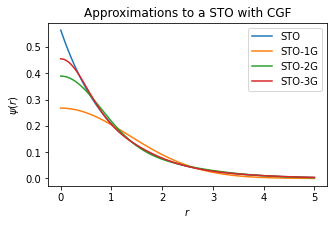

In [820]:
#  import some libraries (numpy,scipy,matplot)
import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt

r = np.linspace(0,5,num=1000)
zeta = 1.0
psi_STO = (zeta**3/np.pi)**(0.5)*np.exp(-zeta*r)

# Coeff is the d_n variable in the equation 
Coeff = np.array([[1.00000,0.0000000,0.000000],  #coefficient for STO-1G (d1=1,d2=0,d2=0)
                  [0.678914,0.430129,0.000000],  #coefficient for STO-2G (d1=.67..,d2=.43..,d2=0)
                  [0.444635,0.535328,0.154329]]) #coefficient for STO-3G (d1=.44..,d2=.53..,d2=.15..)

# Expon is the alpha,beta,gamma variable in the equation 
Expon = np.array([[0.270950,0.000000,0.000000],  #exponents for STO-1G(zi1=.27..,zi2=0,zi3=0)
                  [0.151623,0.851819,0.000000],  #exponents for STO-2G(zi1=.15..,zi2=.85..,zi3=0)
                  [0.109818,0.405771,2.227660]]) #exponents for STO-3G(zi1=.10..,zi2=.40..,zi3=2.227..)

psi_CGF_STO1G = Coeff[0,0]*(2*Expon[0,0]/np.pi)**(0.75)*np.exp(-Expon[0,0]*r**2)
psi_CGF_STO2G = Coeff[1,0]*(2*Expon[1,0]/np.pi)**(0.75)*np.exp(-Expon[1,0]*r**2) \
                + Coeff[1,1]*(2*Expon[1,1]/np.pi)**(0.75)*np.exp(-Expon[1,1]*r**2) \
                + Coeff[1,2]*(2*Expon[1,2]/np.pi)**(0.75)*np.exp(-Expon[1,2]*r**2)
psi_CGF_STO3G = Coeff[2,0]*(2*Expon[2,0]/np.pi)**(0.75)*np.exp(-Expon[2,0]*r**2) \
                + Coeff[2,1]*(2*Expon[2,1]/np.pi)**(0.75)*np.exp(-Expon[2,1]*r**2) \
                + Coeff[2,2]*(2*Expon[2,2]/np.pi)**(0.75)*np.exp(-Expon[2,2]*r**2)
    
# Plot the three functions
plt.figure(figsize=(5,3))
plt.title("Approximations to a STO with CGF")
plt.plot(r,psi_STO,label="STO")
plt.plot(r,psi_CGF_STO1G,label="STO-1G")
plt.plot(r,psi_CGF_STO2G,label="STO-2G")
plt.plot(r,psi_CGF_STO3G,label="STO-3G")
plt.xlabel("$r$")
plt.ylabel("$\psi(r)$")
plt.legend()
plt.show()

## 2. Integrals to Compute
- S_int = overlap integral ||
- T_int = Kinetic Energy integral (of electron) ||
- V_int = Nuclear-Electron integral ||
- TwoE  = two electron integral ||

In [821]:
def S_int(A,B,Rab2):

    return (np.pi/(A+B))**1.5*np.exp(-A*B*Rab2/(A+B))

In [822]:
def T_int(A,B,Rab2):
    
    return A*B/(A+B)*(3.0-2.0*A*B*Rab2/(A+B))*(np.pi/(A+B))**1.5*np.exp(-A*B*Rab2/(A+B))

In [823]:
def V_int(A,B,Rab2,Rcp2,Zc):

    return -Zc*2.0*np.pi/(A+B)*F0((A+B)*Rcp2)*np.exp(-A*B*Rab2/(A+B))

### function f(...) 

In [824]:
# Error function from scipy library

def F0(t):

    if (t<1e-6):
        return 1.0-t/3.0
    else:
        return 0.5*(np.pi/t)**0.5*sp.erf(t**0.5) #np.erf for error function from scipy

In [825]:
def TwoE(A,B,C,D,Rab2,Rcd2,Rpq2):

    return 2.0*(np.pi**2.5)/((A+B)*(C+D)*np.sqrt(A+B+C+D))*F0((A+B)*(C+D)*Rpq2/(A+B+C+D))*np.exp(-A*B*Rab2/(A+B)-C*D*Rcd2/(C+D))


- alpha has been rescalled as $\alpha = \alpha(1.0)*\zeta^2$  [szabo page = 158]

In [826]:
def Intgrl(N,R,Zeta1,Zeta2,Za,Zb):

    global S12,T11,T12,T22,V11A,V12A,V22A,V11B,V12B,V22B,V1111,V2111,V2121,V2211,V2221,V2222
     
    S12 = 0.0
    T11 = 0.0 ; T12 = 0.0 ; T22 = 0.0
    V11A = 0.0 ; V12A = 0.0 ; V22A = 0.0 ; V11B = 0.0 ; V12B = 0.0 ; V22B = 0.0
    V1111 = 0.0 ; V2111 = 0.0 ;  V2121 = 0.0 ; V2211 = 0.0 ; V2221 = 0.0 ; V2222 = 0.0
    
    R2 = R*R   #(squre of R)
    

    # The coefficients and exponents for STO-nG are below
    Coeff = np.array([[1.00000,0.0000000,0.000000],     #coefficient for STO-1G (d1=1,d2=0,d2=0)
                      [0.678914,0.430129,0.000000],     #coefficient for STO-2G (d1=.67..,d2=.43..,d2=0)
                      [0.444635,0.535328,0.154329]])    #coefficient for STO-3G (d1=.44..,d2=.53..,d2=.15..
    
    Expon = np.array([[0.270950,0.000000,0.000000],     #exponents for STO-1G(zi1=.27..,zi2=0,zi3=0)
                      [0.151623,0.851819,0.000000],     #exponents for STO-2G(zi1=.15..,zi2=.85..,zi3=0)
                      [0.109818,0.405771,2.227660]])    #exponents for STO-3G(zi1=.10..,zi2=.40..,zi3=2.227..)

    
    D1 = np.zeros([3])
    A1 = np.zeros([3])
    D2 = np.zeros([3])
    A2 = np.zeros([3])
    
   
    # This loop constructs the exponents of the STO-nG
    for i in range(N):
        print("The coefficients STO-NG:",Coeff[N-1,i])   
        A1[i] = Expon[N-1,i]*(Zeta1**2)   #scaling factor (alpha=alpha(zeta=1.0)*zeta**2)
        D1[i] = Coeff[N-1,i]*((2.0*A1[i]/np.pi)**0.75)  #rescaled coefficient
        A2[i] = Expon[N-1,i]*(Zeta2**2)   #scaling factor (beta=beta(zeta=1.0)*zeta**2)
        D2[i] = Coeff[N-1,i]*((2.0*A2[i]/np.pi)**0.75) #rescalled coefficient
    
    # Calculate one electron integrals 
    for i in range(N):
        for j in range(N):
            # Rap2 - squared distance between centre A and centre P
            Rap = A2[j]*R/(A1[i]+A2[j]) 
            Rap2 = Rap**2
            Rbp2 = (R-Rap)**2
            S12 = S12 + S_int(A1[i],A2[j],R2)*D1[i]*D2[j]
            T11 = T11 + T_int(A1[i],A1[j],0.0)*D1[i]*D1[j]
            T12 = T12 + T_int(A1[i],A2[j],R2)*D1[i]*D2[j]
            T22 = T22 + T_int(A2[i],A2[j],0.0)*D2[i]*D2[j]
            V11A = V11A + V_int(A1[i],A1[j],0.0,0.0,Za)*D1[i]*D1[j]
            V12A = V12A + V_int(A1[i],A2[j],R2,Rap2,Za)*D1[i]*D2[j]
            V22A = V22A + V_int(A2[i],A2[j],0.0,R2,Za)*D2[i]*D2[j]
            V11B = V11B + V_int(A1[i],A1[j],0.0,R2,Zb)*D1[i]*D1[j]
            V12B = V12B + V_int(A1[i],A2[j],R2,Rbp2,Zb)*D1[i]*D2[j]
            V22B = V22B + V_int(A2[i],A2[j],0.0,0.0,Zb)*D2[i]*D2[j]
    
    # Calculate two electron integrals
    
    for i in range(N):
        for j in range(N):
            for k in range(N):
                for l in range(N):
                    Rap = A2[i]*R/(A2[i]+A1[j])
                    Rbp = R - Rap
                    Raq = A2[k]*R/(A2[k]+A1[l])
                    Rbq = R - Raq
                    Rpq = Rap - Raq
                    Rap2 = Rap*Rap
                    Rbp2 = Rbp*Rbp
                    Raq2 = Raq*Raq
                    Rbq2 = Rbq*Rbq
                    Rpq2 = Rpq*Rpq
                    V1111 = V1111 + TwoE(A1[i],A1[j],A1[k],A1[l],0.0,0.0,0.0)*D1[i]*D1[j]*D1[k]*D1[l]
                    V2111 = V2111 + TwoE(A2[i],A1[j],A1[k],A1[l],R2,0.0,Rap2)*D2[i]*D1[j]*D1[k]*D1[l]
                    V2121 = V2121 + TwoE(A2[i],A1[j],A2[k],A1[l],R2,R2,Rpq2)*D2[i]*D1[j]*D2[k]*D1[l]
                    V2211 = V2211 + TwoE(A2[i],A2[j],A1[k],A1[l],0.0,0.0,R2)*D2[i]*D2[j]*D1[k]*D1[l]
                    V2221 = V2221 + TwoE(A2[i],A2[j],A2[k],A1[l],0.0,R2,Rbq2)*D2[i]*D2[j]*D2[k]*D1[l]
                    V2222 = V2222 + TwoE(A2[i],A2[j],A2[k],A2[l],0.0,0.0,0.0)*D2[i]*D2[j]*D2[k]*D2[l]
    return 

In [827]:
def Colect(N,R,Zeta1,Zeta2,Za,Zb):

    # Form core hamiltonian(H)
    H[0,0] = T11+V11A+V11B
    H[0,1] = T12+V12A+V12B
    H[1,0] = H[0,1]
    H[1,1] = T22+V22A+V22B

    # Form overlap matrix(S)
    S[0,0] = 1.0
    S[0,1] = S12
    S[1,0] = S12
    S[1,1] = 1.0
    
    #Form Kintic energy Matrix(T)
    T[0,0] = T11
    T[0,1] = T12
    T[1,0] = T12
    T[1,1] = T22
    
    #Form Potential energy Matrix(V)
    V[0,0] = V11A+V11B
    V[0,1] = V12A+V12B
    V[1,0] = V12A+V12B
    V[1,1] = V22A+V22B
    
    # This is S^-1/2=X
    X[0,0] = 1.0/np.sqrt(2.0*(1.0+S12))
    X[1,0] = X[0,0]
    X[0,1] = 1.0/np.sqrt(2.0*(1.0-S12))
    X[1,1] = -X[0,1]
    """
    SVAL, SVEC   = np.linalg.eigh(S) # Diagonalize basis using symmetric orthogonalization 
    SVAL_minhalf = (np.diag(SVAL**(-0.5))) # Inverse square root of eigenvalues
    S_minhalf    = np.dot(SVEC, np.dot(SVAL_minhalf, np.transpose(SVEC)))
    """
    
    # This is the coulomb term = (aa|bb) and exchange = (ab|ba)
    TT[0,0,0,0] = V1111
    TT[1,0,0,0] = V2111
    TT[0,1,0,0] = V2111
    TT[0,0,1,0] = V2111
    TT[0,0,0,1] = V2111
    TT[1,0,1,0] = V2121
    TT[0,1,1,0] = V2121
    TT[1,0,0,1] = V2121
    TT[0,1,0,1] = V2121
    TT[1,1,0,0] = V2211
    TT[0,0,1,1] = V2211
    TT[1,1,1,0] = V2221
    TT[1,1,0,1] = V2221
    TT[1,0,1,1] = V2221
    TT[0,1,1,1] = V2221
    TT[1,1,1,1] = V2222

## 3. Self consistent field calculation

In [828]:
def SCF(N,R,Zeta1,Zeta2,Za,Zb,G):
    
    Crit = 1e-4 # Convergence critera is 10^-4
    Maxit = 100 # Maximum number of iterations
    Iter=0
    
    #+++++++++STEP 1. Guess an initial density matrix++++++++ #
    # Use core hamiltonian for initial guess of F, >> Initial density matrix P=0
    P = np.zeros([2,2])
    
    Energy = 0.0
    
    while (Iter<Maxit):
        Iter += 1
        #print("Iteration:",Iter)
        
        #+++++++++ STEP 2. calculate the Fock matrix +++++++++#
        # Form two electron part of Fock matrix from P
        G = np.zeros([2,2]) # This is the two electron contribution in the equations above
        for i in range(2):
            for j in range(2):
                for k in range(2):
                    for l in range(2):
                        G[i,j]=G[i,j]+P[k,l]*(TT[i,j,k,l]-0.5*TT[i,j,k,l])

        # Add core hamiltonian H^CORE to get fock matrix
        F = H+G
        
        # Calculate the electronic energy
        Energy = np.sum(0.5*P*(H+F))
        
        #print('Electronic energy = ',Energy)
        
        #+++++++++ STEP 3. Calculate F' (remember S^-1/2 is X and S^1/2 is X.T)+++++++++#
        G = np.matmul(F,X)
        #print("matrix G:\n",G)
        Fprime = np.matmul(X.T,G)
        #print("Foc_prime Matrix\n",Fprime)
        #-------------------------
        #+++++++++ STEP 4.+++++++++#
        # Diagonalize F' matrix
        # E are eigenvalues of F' matrix
        # Cprime are eigenvectors of F' matrix
        E, Cprime = np.linalg.eigh(Fprime)
        #-------------------------
        
        #+++++++++ STEP 5. Calculate the molecular orbitals coefficients +++++++++#
        # Transform eigen vectors to get matrix C
        C = np.matmul(X,Cprime)
               
        #+++++++++ STEP 6. Calculate the new density matrix from the old P +++++++++#
        Oldp = np.array(P)
        #print("Old density mat:\n",Oldp)
        P= np.zeros([2,2])
        
        # Form new density matrix
        for i in range(2):
            for j in range(2):
                #Save present density matrix before creating a new one
                for k in range(1):
                    P[i,j] += 2.0*C[i,k]*C[j,k]
                    
        #print("New density mat:\n",P)

        #+++++++++ STEP 7. Check to see if the energy has converged +++++++++#
        Delta = 0.0
        # Calculate delta the difference between the old density matrix Old P and the new P
        Delta = (P-Oldp)
        Delta = np.sqrt(np.sum(Delta**2))
        
        #Check for convergence
        if (Delta<Crit):
            print("Number of iteration:",Iter)
            # Add nuclear repulsion to get the total energy
            SCF.Energytot = Energy+Za*Zb/R     #Vnn =(Za*Zb)/R is a constant term
            print("Nuclear repulsion:",Za*Zb/R )
            print("Converged electronic energy:",Energy)
            print("Converged total energy:",SCF.Energytot)
            #print("Converged density matrix\n",P)
            break

### Calling all the functions for calculation

In [829]:
def HFCALC(N,R,Zeta1,Zeta2,Za,Zb,G):

    # Calling one and two electron integrals
    Intgrl(N,R,Zeta1,Zeta2,Za,Zb)
    # Puting all integals into array
    Colect(N,R,Zeta1,Zeta2,Za,Zb)
    # Performing the SCF calculation
    SCF(N,R,Zeta1,Zeta2,Za,Zb,G,)
    return

### Global Variable declearation

In [830]:
global H,S,X,XT,TT,G,C,P,Oldp,F,Fprime,Cprime,E,Zb,Energytot

#One time calculation matrices(T,V,S,H=T+V)
H = np.zeros([2,2])      #'''Core Halitonian Matrix(H)'''
S = np.zeros([2,2])      #'''Overlap Matrix(S)'''
T = np.zeros([2,2])      #'''Kinetic Energy Matrix(T)'''
V = np.zeros([2,2])      #'''Potential Energy Matrix(T)'''

X = np.zeros([2,2])      #'''X=S^-1/2'''
XT = np.zeros([2,2])     #'''XT=S^1/2'''
TT = np.zeros([2,2,2,2]) #'''TwoE matrix'''
G = np.zeros([2,2])      #'''G=P*TT'''
C = np.zeros([2,2])      #'''coefficient Matrix(C)'''
 
P = np.zeros([2,2])      #'''Desnsity Matrix(P)'''
Oldp = np.zeros([2,2])   #'''Old density Matrix'''
F = np.zeros([2,2])      #'''Fock Matrix(F)'''
Fprime = np.zeros([2,2]) #'''new Fock Matrix(F')'''
Cprime = np.zeros([2,2]) 
E = np.zeros([2,2])      #'''Energy of obrital(diagonals of the matrix)'''

Energy = 0.0
Delta = 0.0

### SYSTEM INFORMATION
- Change value of N to go from STO-1G to STO-3G
- set (N = 3) for STO-3G
- set (N = 2) for STO-2G
- set (N = 1) for STO-1G 
- +++++++++++++++++++++++++++++++++++++++++++++++++++++++++
- R = 1.34  (taken from szabo to match the result)
- $\zeta = 1.24 $  (taken from szabo to matched the result)
- ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
- Za = Zb = 1 (Hydrogen)


In [831]:
#////system of interest/////
#-----H2 molecule-----------#
N = 3  # N = 3for STO-3G, N=2 for STO-2G, N=1 for STO-1G 
R = 1.34 #radial distance (taken from szabo)
Zeta1 = 1.24  # exponent for sto-3g H2 molecule(taken from szabo)
Zeta2 = 1.24  # page=168 szabo
Za = 1.0  #nucleus 1 ZA = 1 (hydrogen)
Zb = 1.0  #nucleus 1 ZB = 1 (hydrogen)
HFCALC(N,R,Zeta1,Zeta2,Za,Zb,G)

The coefficients STO-NG: 0.444635
The coefficients STO-NG: 0.535328
The coefficients STO-NG: 0.154329
Number of iteration: 2
Nuclear repulsion: 0.7462686567164178
Converged electronic energy: -1.8637653959972074
Converged total energy: -1.1174967392807895


### Printing the matrices

In [832]:
print("Overlap Matrix:\n",S)

Overlap Matrix:
 [[1.         0.68012275]
 [0.68012275 1.        ]]


In [833]:
print("matrix X=S^-1/2\n",X)

matrix X=S^-1/2
 [[ 0.5455248   1.25023982]
 [ 0.5455248  -1.25023982]]


In [834]:
print("Kinetic Energy Matrix:\n",T)

Kinetic Energy Matrix:
 [[0.76003294 0.25581734]
 [0.25581734 0.76003294]]


In [835]:
print("Potential Energy Matrix:\n",V)

Potential Energy Matrix:
 [[-1.90148796 -1.25183193]
 [-1.25183193 -1.90148796]]


In [836]:
print("T+V:\n",T+V)

T+V:
 [[-1.14145501 -0.99601459]
 [-0.99601459 -1.14145501]]


In [837]:
print("Core Hamiltonian\n",H)

Core Hamiltonian
 [[-1.14145501 -0.99601459]
 [-0.99601459 -1.14145501]]


### Plot of Energy vs Radial distance for different R(.75-3.0)
- R varied from .75 to 3.0 
- $\zeta = 1.24$ (to matched result from szabo)

In [838]:
rr =0.01*(np.linspace(75,300,100))
EE = [] ; RR = []
for ir in rr:
    R = ir
    print("++++++++++++++++++++++++++++++++++++++++++")
    print("Raidaial distance:",R)
    HFCALC(N,R,Zeta1,Zeta2,Za,Zb,G)
    
    EE.append(SCF.Energytot)
    RR.append(R)
    #print("ENEGY:",SCF.Energytot)    

++++++++++++++++++++++++++++++++++++++++++
Raidaial distance: 0.75
The coefficients STO-NG: 0.444635
The coefficients STO-NG: 0.535328
The coefficients STO-NG: 0.154329
Number of iteration: 2
Nuclear repulsion: 1.3333333333333333
Converged electronic energy: -2.2313337839736795
Converged total energy: -0.8980004506403463
++++++++++++++++++++++++++++++++++++++++++
Raidaial distance: 0.7727272727272727
The coefficients STO-NG: 0.444635
The coefficients STO-NG: 0.535328
The coefficients STO-NG: 0.154329
Number of iteration: 2
Nuclear repulsion: 1.2941176470588236
Converged electronic energy: -2.215819318094138
Converged total energy: -0.9217016710353143
++++++++++++++++++++++++++++++++++++++++++
Raidaial distance: 0.7954545454545455
The coefficients STO-NG: 0.444635
The coefficients STO-NG: 0.535328
The coefficients STO-NG: 0.154329
Number of iteration: 2
Nuclear repulsion: 1.2571428571428571
Converged electronic energy: -2.20038541725002
Converged total energy: -0.943242560107163
+++++++

Number of iteration: 2
Nuclear repulsion: 0.5301204819277109
Converged electronic energy: -1.596728970950362
Converged total energy: -1.0666084890226513
++++++++++++++++++++++++++++++++++++++++++
Raidaial distance: 1.9090909090909094
The coefficients STO-NG: 0.444635
The coefficients STO-NG: 0.535328
The coefficients STO-NG: 0.154329
Number of iteration: 2
Nuclear repulsion: 0.5238095238095237
Converged electronic energy: -1.5870230933965588
Converged total energy: -1.063213569587035
++++++++++++++++++++++++++++++++++++++++++
Raidaial distance: 1.9318181818181819
The coefficients STO-NG: 0.444635
The coefficients STO-NG: 0.535328
The coefficients STO-NG: 0.154329
Number of iteration: 2
Nuclear repulsion: 0.5176470588235293
Converged electronic energy: -1.5774158953492
Converged total energy: -1.0597688365256706
++++++++++++++++++++++++++++++++++++++++++
Raidaial distance: 1.9545454545454548
The coefficients STO-NG: 0.444635
The coefficients STO-NG: 0.535328
The coefficients STO-NG: 0.1

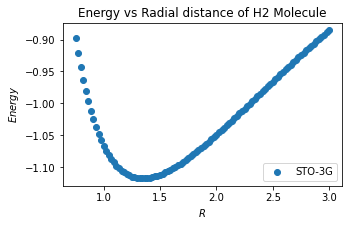

In [839]:
plt.figure(figsize=(5,3))
plt.title("Energy vs Radial distance of H2 Molecule")
plt.scatter(RR,EE,label='STO-3G')
plt.xlabel("$R$")
plt.ylabel("$Energy$")
plt.legend()
plt.show()

### Minimum Energy and Corresponding R

In [840]:
#minenergy = min(EE)
#minenergy_index = EE.index(min(EE))
#print("minimum energy:",minenergy,"Corresponding to R:",RR[minenergy_index])
print("minimum energy:",min(EE),"Corresponding to R:",RR[EE.index(min(EE))])

minimum energy: -1.1174996105323416 Corresponding to R: 1.340909090909091
